<a href="https://colab.research.google.com/github/dhruvjoshi0905/Hack-O-Week/blob/main/hack_o_week_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Anomaly Detection Project: Heart Rate Data

This notebook will guide you through setting up a basic anomaly detection system using the Isolation Forest algorithm on synthetic heart rate data. We'll cover data generation, model training, anomaly detection, and touch upon how one might expose this functionality via a REST API.

Generated 1020 data points.


,heart_rate
0,77.852993
1,79.348030
2,66.862288
3,84.261391
4,75.546974


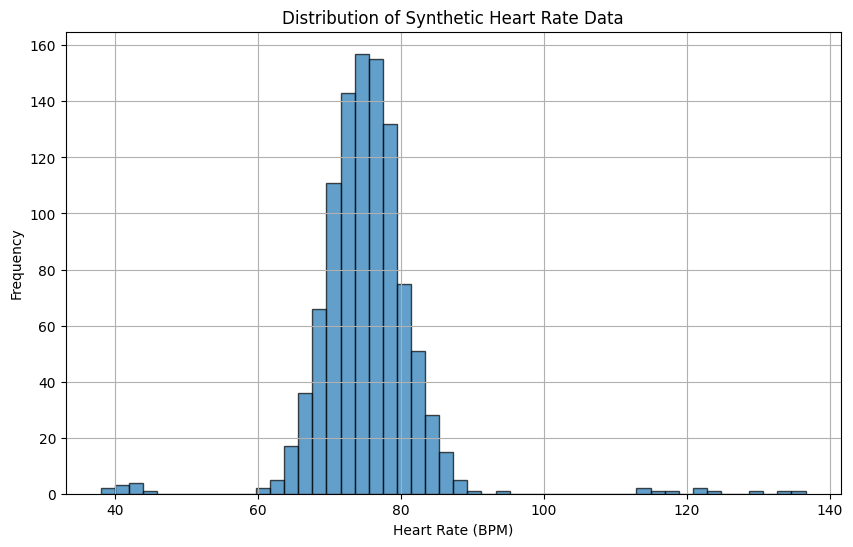

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Set random seed for reproducibility
np.random.seed(42)

# Generate normal heart rate data
# Assume a normal resting heart rate distribution around 70-90 BPM
normal_hr = np.random.normal(loc=75, scale=5, size=1000)
normal_hr = np.clip(normal_hr, 60, 100) # Keep heart rates within a plausible normal range

# Generate some anomalies
anomaly_hr_low = np.random.normal(loc=40, scale=3, size=10) # Very low heart rates
anomaly_hr_high = np.random.normal(loc=120, scale=8, size=10) # Very high heart rates

# Combine normal and anomaly data
heart_rate_data = np.concatenate([normal_hr, anomaly_hr_low, anomaly_hr_high])

# Create a DataFrame
df = pd.DataFrame({'heart_rate': heart_rate_data})

# Shuffle the data to mix normal and anomalous points
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Generated {len(df)} data points.")
display(df.head())

# Visualize the data distribution
plt.figure(figsize=(10, 6))
plt.hist(df['heart_rate'], bins=50, edgecolor='k', alpha=0.7)
plt.title('Distribution of Synthetic Heart Rate Data')
plt.xlabel('Heart Rate (BPM)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


#### 2. Train Isolation Forest Model

Now, we'll train an Isolation Forest model. Isolation Forest works by isolating anomalies rather than profiling normal data points. It's particularly effective for high-dimensional datasets but works well for single features too.

Key parameters:
- `contamination`: The proportion of outliers in the data set. This is a crucial parameter. If you know the approximate percentage of anomalies, set it here. Otherwise, you might need to tune it.
- `random_state`: For reproducibility.

In [2]:
# Initialize the Isolation Forest model
# We estimate contamination to be around 2% (20 anomalies out of 1020 total points)
model = IsolationForest(contamination=0.02, random_state=42)

# Train the model
# The model expects a 2D array, so we reshape the single 'heart_rate' column
model.fit(df[['heart_rate']])

print("Isolation Forest model trained successfully!")


Isolation Forest model trained successfully!


#### 3. Detect Anomalies

After training, we can use the model to predict anomalies. The `predict` method will return -1 for outliers and 1 for inliers. The `decision_function` method returns anomaly scores, where lower scores indicate a higher likelihood of being an anomaly.

Number of detected anomalies: 21


,heart_rate,anomaly_prediction,anomaly_score
32,41.180456,-1,-0.081825
100,42.685580,-1,-0.074416
136,38.394294,-1,-0.094692
149,121.583286,-1,-0.092533
256,133.887710,-1,-0.117717


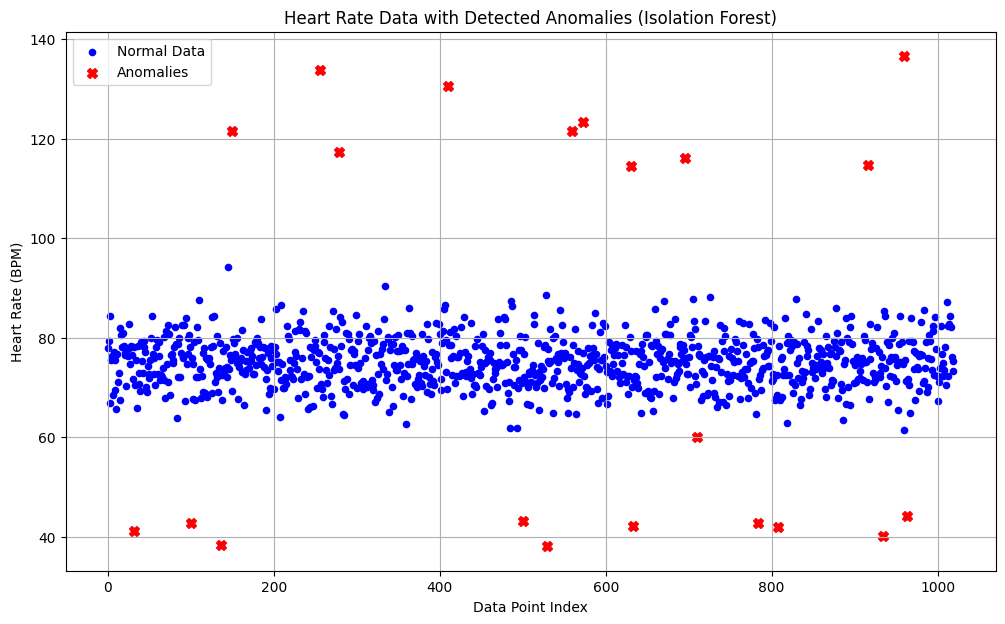

In [3]:
# Predict anomalies
df['anomaly_prediction'] = model.predict(df[['heart_rate']])
df['anomaly_score'] = model.decision_function(df[['heart_rate']])

# Identify actual anomalies (-1)
anomalies = df[df['anomaly_prediction'] == -1]

print(f"Number of detected anomalies: {len(anomalies)}")
display(anomalies.head())

# Visualize the results
plt.figure(figsize=(12, 7))
plt.scatter(df.index, df['heart_rate'], c='blue', label='Normal Data', s=20)
plt.scatter(anomalies.index, anomalies['heart_rate'], c='red', label='Anomalies', s=50, marker='X')
plt.title('Heart Rate Data with Detected Anomalies (Isolation Forest)')
plt.xlabel('Data Point Index')
plt.ylabel('Heart Rate (BPM)')
plt.legend()
plt.grid(True)
plt.show()


#### 4. Expose Anomaly Detection via a REST API (Conceptual)

To make this anomaly detection system accessible, you could expose it as a REST API. This would allow other applications or services to send heart rate data and receive anomaly predictions in return. A common way to do this in Python is using a micro-framework like Flask or FastAPI.

Here's a conceptual outline and a basic Flask example for how you might set this up. Note that running a full Flask application directly within a Colab notebook for external access is generally not straightforward without additional tools like `ngrok` for tunneling, or deploying to a cloud platform. This example focuses on the API structure.

**Key components of the API:**
1.  **Serialization/Deserialization**: Handle incoming JSON data (e.g., a new heart rate reading) and outgoing JSON responses.
2.  **Prediction Endpoint**: A specific URL (`/predict_anomaly`) that listens for incoming requests.
3.  **Model Loading**: The trained `IsolationForest` model needs to be loaded (or made globally available if defined in the same script).
4.  **Prediction Logic**: Use the loaded model to make predictions on new data.



In [4]:
import flask
from flask import request, jsonify
import joblib # For saving and loading the model

# --- 4.1 Save the trained model ---
# In a real-world scenario, you would save your trained model to a file
# and load it when the API starts. This avoids retraining every time.
model_filename = 'isolation_forest_model.pkl'
joblib.dump(model, model_filename)
print(f"Model saved to {model_filename}")

# --- 4.2 Define the Flask API (conceptual) ---

# This part of the code is for demonstration of API structure.
# Running a Flask app directly in Colab for external access requires tools like ngrok.

app = flask.Flask(__name__)
app.config["DEBUG"] = True

# Load the model once when the API starts
loaded_model = joblib.load(model_filename)
print("Model loaded for API.")

@app.route('/', methods=['GET'])
def home():
    return "<h1>Anomaly Detection API</h1><p>This site is a prototype API for heart rate anomaly detection.</p>"

@app.route('/predict_anomaly', methods=['POST'])
def predict_anomaly():
    if request.is_json:
        data = request.get_json()
        if 'heart_rate' not in data:
            return jsonify({'error': 'Missing heart_rate in request body'}), 400

        try:
            new_heart_rate = float(data['heart_rate'])
            # Model expects a 2D array
            prediction = loaded_model.predict(np.array([[new_heart_rate]])) # -1 for anomaly, 1 for normal
            score = loaded_model.decision_function(np.array([[new_heart_rate]]))[0] # Anomaly score

            is_anomaly = True if prediction[0] == -1 else False

            response = {
                'heart_rate': new_heart_rate,
                'is_anomaly': is_anomaly,
                'anomaly_score': float(score) # Convert numpy float to Python float
            }
            return jsonify(response), 200

        except ValueError:
            return jsonify({'error': 'Invalid heart_rate value. Must be a number.'}), 400
        except Exception as e:
            return jsonify({'error': f'An internal error occurred: {str(e)}'}), 500
    else:
        return jsonify({'error': 'Request must be JSON'}), 400

# To run this API in a local environment, you would typically use:
# if __name__ == '__main__':
#    app.run(host='0.0.0.0', port=5000)

print("Flask API endpoints defined. You would run this with a WSGI server (e.g., Gunicorn) in production.")
print("To test locally (outside Colab), save this as app.py and run 'flask run'.")


Model saved to isolation_forest_model.pkl
Model loaded for API.
Flask API endpoints defined. You would run this with a WSGI server (e.g., Gunicorn) in production.
To test locally (outside Colab), save this as app.py and run 'flask run'.


#### 5. Conclusion

This notebook demonstrated the full workflow for setting up a basic anomaly detection system on synthetic heart rate data using Isolation Forest, from data generation and model training to anomaly detection and visualization. It also provided a conceptual framework for how such a model could be exposed via a REST API, enabling integration with other applications.